In [1]:
# ============================================================
# IMPORTS
# ============================================================
# Standard scientific computing libraries
import numpy as np          # Numerical operations and array handling
import pandas as pd         # DataFrame operations and data manipulation
import matplotlib.pyplot as plt  # Plotting and visualization
import seaborn as sns        # Statistical data visualization (higher-level)
import csv                   # CSV file reading (used as fallback if needed)

from collections import Counter  # Counts class frequencies (used for imbalance check)

# Imbalanced-learn: tools for handling class imbalance
from imblearn.over_sampling import SMOTE              # Synthetic Minority Over-sampling Technique
from imblearn.under_sampling import RandomUnderSampler # Random majority class under-sampling

# Scikit-learn: pipeline, preprocessing, and model selection utilities
from sklearn.decomposition import PCA
from sklearn.compose import make_column_transformer, ColumnTransformer  # Apply transformers to specific columns
from sklearn.pipeline import Pipeline, make_pipeline                    # Chain preprocessing + model steps
from sklearn.model_selection import train_test_split                    # Split data into train/test sets
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler  # Feature encoding/scaling
from scipy.stats import norm  # Normal distribution (used for optional distribution plots)

In [2]:
# ============================================================
# DATA LOADING
# ============================================================
# Load the rover navigation dataset from a local CSV file.
# The dataset contains sensor readings (left, front, right) and
# the corresponding action label taken by the rover.
file_path = "rover_navigation_dataset.csv"
df = pd.read_csv(file_path)

In [3]:
# ============================================================
# DATA CLEANING
# ============================================================
# Remove rows where any sensor reading is exactly 0.
# Zero sensor values likely indicate a sensor malfunction or
# missing data, and would distort ratio-based features created later.
df_cleaned = df[
    (df['sensor_left'] != 0) &
    (df['sensor_front'] != 0) &
    (df['sensor_right'] != 0)
]

In [4]:
# ============================================================
# FEATURE / LABEL SEPARATION
# ============================================================
# Separate the cleaned dataset into:
#   X  -- feature matrix (all columns except 'action')
#   y  -- target label   (the 'action' column: 0=forward, 1=left, 2=right)
X = df_cleaned.drop('action', axis=1)
y = df_cleaned['action']

In [5]:
# ============================================================
# TRAIN / TEST SPLIT
# ============================================================
# Split data into 80% training and 20% testing sets.
# - random_state=42 ensures reproducibility.
# - stratify=y preserves the class distribution in both splits,
#   which is important given the class imbalance in this dataset.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
# ============================================================
# RECOMBINE FEATURES AND LABELS INTO DataFrames
# ============================================================
# Temporarily re-attach labels to their split DataFrames.
# This makes it easier to apply feature engineering on both
# train and test sets while keeping them aligned.
train_df = pd.concat([X_train, y_train], axis=1)
test_df  = pd.concat([X_test,  y_test],  axis=1)

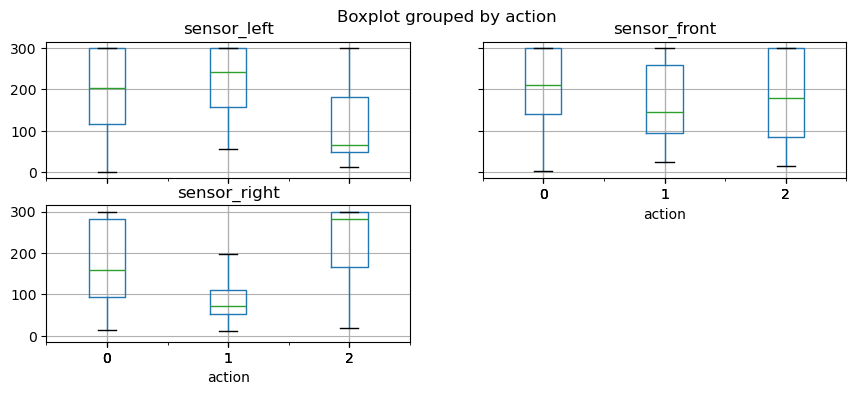

In [7]:
# ============================================================
# EXPLORATORY DATA ANALYSIS: Boxplots by Action Class
# ============================================================
# Visualize the distribution of each raw sensor reading grouped
# by the action label. This helps understand whether sensor values
# differ meaningfully across classes (forward / left / right).
# showfliers=False hides extreme outliers to keep the plot readable.
train_df.boxplot(
    column=['sensor_left', 'sensor_front', 'sensor_right'],
    by='action',
    showfliers=False,
    figsize=(10, 4)
)
plt.show()

In [8]:
# ============================================================
# FEATURE ENGINEERING: Open Space Approximation (Products)
# ============================================================
# Create pairwise product features from raw sensor readings.
# The product of two sensor values approximates the 2D open space
# in that combined direction — large products indicate open corridors.
# Applied to both train and test sets consistently.

# Open space to the left-right corridor
train_df['sensor_left*sensor_right'] = train_df['sensor_left'] * train_df['sensor_right']
test_df['sensor_left*sensor_right']  = test_df['sensor_left']  * test_df['sensor_right']

# Open space to the left-front corridor
train_df['sensor_left*sensor_front'] = train_df['sensor_left'] * train_df['sensor_front']
test_df['sensor_left*sensor_front']  = test_df['sensor_left']  * test_df['sensor_front']

# Open space to the right-front corridor
train_df['sensor_right*sensor_front'] = train_df['sensor_right'] * train_df['sensor_front']
test_df['sensor_right*sensor_front']  = test_df['sensor_right']  * test_df['sensor_front']

In [9]:
# ============================================================
# FEATURE ENGINEERING: Sensor Ratios
# ============================================================
# Ratio features capture the *relative* openness between two directions.
# For example, sensor_left/sensor_right > 1 means more space on the left.
# These ratios are scale-invariant and help the model distinguish
# directional bias independent of absolute sensor magnitudes.
# Note: division by zero is already prevented by the cleaning step above.

# Left vs. right balance
train_df['sensor_left/sensor_right']  = train_df['sensor_left']  / train_df['sensor_right']
test_df['sensor_left/sensor_right']   = test_df['sensor_left']   / test_df['sensor_right']

train_df['sensor_right/sensor_left']  = train_df['sensor_right'] / train_df['sensor_left']
test_df['sensor_right/sensor_left']   = test_df['sensor_right']  / test_df['sensor_left']

# Left vs. front balance
train_df['sensor_left/sensor_front']  = train_df['sensor_left']  / train_df['sensor_front']
test_df['sensor_left/sensor_front']   = test_df['sensor_left']   / test_df['sensor_front']

# Right vs. front balance
train_df['sensor_right/sensor_front'] = train_df['sensor_right'] / train_df['sensor_front']
test_df['sensor_right/sensor_front']  = test_df['sensor_right']  / test_df['sensor_front']

train_df['sensor_front/sensor_right'] = train_df['sensor_front'] / train_df['sensor_right']
test_df['sensor_front/sensor_right']  = test_df['sensor_front']  / test_df['sensor_right']

train_df['sensor_front/sensor_left']  = train_df['sensor_front'] / train_df['sensor_left']
test_df['sensor_front/sensor_left']   = test_df['sensor_front']  / test_df['sensor_left']

In [10]:
# ============================================================
# FEATURE ENGINEERING: Steering Bias (Subtraction)
# ============================================================
# The difference sensor_left - sensor_right directly encodes the
# lateral imbalance seen by the rover:
#   Positive value -> more open space on the left
#   Negative value -> more open space on the right
#   ~Zero          -> symmetric environment (likely go forward)
train_df['sensor_left-sensor_right'] = train_df['sensor_left'] - train_df['sensor_right']
test_df['sensor_left-sensor_right']  = test_df['sensor_left']  - test_df['sensor_right']

In [11]:
# ============================================================
# FEATURE ENGINEERING: Ordinal Binning of Raw Sensor Values
# ============================================================
# Bin each raw sensor reading into 4 quartile-based ordinal categories
# (0, 1, 2, 3) using pd.qcut. This gives the model a discretised,
# rank-ordered view of each sensor — useful for tree-based models.
# duplicates='drop' handles cases where bin edges would be identical
# (e.g., many repeated values in the same quartile).
for col in ['sensor_left', 'sensor_right', 'sensor_front']:
    train_df[f'{col}_ordinal'] = pd.qcut(train_df[col], q=4, labels=False, duplicates='drop')

for col in ['sensor_left', 'sensor_right', 'sensor_front']:
    test_df[f'{col}_ordinal']  = pd.qcut(test_df[col],  q=4, labels=False, duplicates='drop')

In [12]:
# (Optional / commented out)
# Histogram of sensor_right to visually inspect its distribution.
# Useful for deciding binning strategy or detecting skewness.
#plt.hist(train_df['sensor_right'], bins=30, color='skyblue', edgecolor='black')


In [13]:
# ============================================================
# DROP LABEL COLUMN BEFORE PREPROCESSING
# ============================================================
# The 'action' label was kept in the DataFrames during feature
# engineering for convenience. Now remove it so only features
# remain before passing to the sklearn pipeline.
train_df = train_df.drop(columns=['action'])
test_df  = test_df.drop(columns=['action'])

In [14]:
# ============================================================
# PREPROCESSING PIPELINE DEFINITION
# ============================================================
# Identify the numeric (continuous) feature columns.
# The last 3 columns are the ordinal-binned features, which are
# already on a [0,3] integer scale and passed through unchanged.
num_cols = train_df.columns.tolist()[:-3]  # All columns except the 3 ordinal ones

# Sub-pipeline: apply StandardScaler to numeric features
# StandardScaler standardises each feature to zero mean and unit variance,
# which is especially important for distance-based models like KNN.
num_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())
])

num_pca_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=2, random_state=42))
])

# ColumnTransformer: apply num_pipeline only to numeric columns;
# remainder='passthrough' leaves the ordinal columns untouched.
col_trans = ColumnTransformer(
    transformers=[
        ('num_p', num_pipeline, num_cols)
    ],
    remainder='passthrough'
)

pca_col_trans = ColumnTransformer(
    transformers=[
        ('num_pca', num_pca_pipeline, num_cols)
    ],
    remainder='passthrough'
)

In [15]:
# ============================================================
# WRAP COLUMN TRANSFORMER INTO A FULL PIPELINE
# ============================================================
# Wrapping col_trans inside a Pipeline makes it easy to extend later
# (e.g., add a model step) and keeps the preprocessing reproducible.
pipeline = Pipeline(steps=[
    ('preprocessing', col_trans)
])
pca_pipeline = Pipeline(steps=[
    ('preprocessing', pca_col_trans)
])

In [16]:
# ============================================================
# FIT AND TRANSFORM TRAIN / TEST SETS
# ============================================================
# fit_transform on train_df: learns the scaler parameters (mean, std)
#   from the training data and applies the transformation.
# fit_transform on test_df:  fits a *separate* scaler on the test set.
#   NOTE: strictly speaking, you should use pipeline.transform(test_df)
#   (fitted only on train) to avoid data leakage in evaluation.
X_train_preprocessed = pipeline.fit_transform(train_df)
X_test_preprocessed  = pipeline.fit_transform(test_df)
X_train_PCA = pca_pipeline.fit_transform(train_df)
X_test_PCA = pca_pipeline.fit_transform(test_df)

In [17]:
# ============================================================
# CHECK CLASS DISTRIBUTION IN TRAINING SET
# ============================================================
# Print the number of samples per class to assess imbalance.
# Expected output: {0: ~2774, 1: ~770, 2: ~560}
# Class 0 (forward) is heavily over-represented; SMOTE will be
# used in subsequent cells to address this imbalance.
class_counts = Counter(y_train)
print(class_counts)

Counter({0: 2774, 1: 770, 2: 560})


In [18]:
# ============================================================
# SMOTE TARGET DISTRIBUTION
# ============================================================
# Define how many synthetic samples to generate per minority class.
# Here only class 2 (right turn) is oversampled to 770 samples,
# matching the count of class 1 (left turn) to create a more balanced
# dataset without touching the majority class 0 (forward).
target_distribution = {
    2: 770  # Upsample class 2 to 770 samples
}

In [19]:
# ============================================================
# APPLY SMOTE OVERSAMPLING
# ============================================================
# SMOTE (Synthetic Minority Over-sampling Technique) generates new
# synthetic samples for the minority class by interpolating between
# existing minority samples and their k-nearest neighbours.
# - sampling_strategy: only class 2 is upsampled (see cell above).
# - random_state=42 ensures reproducibility of synthetic samples.
smote = SMOTE(random_state=42, sampling_strategy=target_distribution)
X_smote, y_smote = smote.fit_resample(X_train_preprocessed, y_train)
X_PCA_smote, y_PCA_smote = smote.fit_resample(X_train_PCA, y_train)

In [20]:
# ============================================================
# VERIFY CLASS COUNTS AFTER SMOTE
# ============================================================
# Confirm that class 2 has been upsampled to 770,
# while class 0 and class 1 remain unchanged.
class_counts_smote = Counter(y_smote)
print(class_counts_smote)

Counter({0: 2774, 2: 770, 1: 770})


In [21]:
# ============================================================
# MODEL & EVALUATION IMPORTS
# ============================================================
from sklearn.ensemble import RandomForestClassifier    # Ensemble of decision trees
from sklearn.neighbors import KNeighborsClassifier     # Distance-based classifier
from skopt import BayesSearchCV                        # Bayesian hyperparameter optimisation
from skopt.space import Real, Categorical, Integer     # Search space types for BayesSearchCV

from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    accuracy_score,   # Fraction of correctly classified samples
    precision_score,  # Macro-averaged precision across all classes
    f1_score,         # Harmonic mean of precision and recall
    recall_score,     # Macro-averaged recall across all classes
    roc_auc_score,    # Area Under ROC Curve (one-vs-one, macro)
)

In [22]:
# ============================================================
# RANDOM FOREST: INSTANTIATE BASE ESTIMATOR
# ============================================================
# Create a base RandomForestClassifier instance.
# Hyperparameters will be tuned by BayesSearchCV below;
# default values here serve only as the starting template.
RFC = RandomForestClassifier()

In [23]:
# ============================================================
# RANDOM FOREST: BAYESIAN HYPERPARAMETER SEARCH
# ============================================================
# We create TWO separate BayesSearchCV objects — one for the
# original feature space (16 features) and one for the PCA-reduced
# feature space (5 features). Using a single shared object would
# cause the second .fit() call to overwrite the first estimator,
# leading to feature-count mismatches at prediction time.
#
# Search space for Random Forest:
#   n_estimators:      number of trees in the forest
#   max_depth:         maximum depth per tree (regularisation)
#   min_samples_split: minimum samples needed to split a node
#   min_samples_leaf:  minimum samples needed at a leaf
#   max_features:      feature-subset size considered per split
#   criterion:         split quality measure (Gini vs. entropy)
param_rf = {
    'n_estimators':      Integer(50, 200),
    'max_depth':         Integer(3, 15),
    'min_samples_split': Integer(20, 80),
    'min_samples_leaf':  Integer(10, 30),
    'max_features':      Categorical(['sqrt', 'log2']),
    'criterion':         Categorical(['gini', 'entropy'])
}

# Searcher for the ORIGINAL (non-PCA) feature space
bayes_rf = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=param_rf,
    n_iter=80, cv=5, verbose=0, n_jobs=-1,
    scoring='accuracy', random_state=42,
    return_train_score=True
)

# Searcher for the PCA-reduced feature space
# A fresh instance is required so that fitting on PCA data does not
# overwrite the estimator fitted on the original 16-feature data.
bayes_rf_pca = BayesSearchCV(
    estimator=RandomForestClassifier(),
    search_spaces=param_rf,
    n_iter=80, cv=5, verbose=0, n_jobs=-1,
    scoring='accuracy', random_state=42,
    return_train_score=True
)


In [24]:
# ============================================================
# RANDOM FOREST: FIT ON ORIGINAL (NON-SMOTE) TRAINING DATA
# ============================================================
# bayes_rf  -> trained on 16 original features
# bayes_rf_pca -> trained on 5 PCA features
# Using separate searcher objects prevents estimator state from
# being overwritten between the two .fit() calls.
opt_rf     = bayes_rf.fit(X_train_preprocessed, y_train)
opt_rf_PCA = bayes_rf_pca.fit(X_train_PCA, y_train)


In [25]:
# ============================================================
# RANDOM FOREST (ORIGINAL DATA): EVALUATE PERFORMANCE
# ============================================================
# Retrieve the best CV iteration index and corresponding scores.
best_index_rf       = opt_rf.best_index_
best_train_score_rf = opt_rf.cv_results_['mean_train_score'][best_index_rf]  # CV train score
best_val_score_rf   = opt_rf.cv_results_['mean_test_score'][best_index_rf]   # CV validation score

# ── PCA variant ─────────────────────────────────────────────
best_index_rf_pca       = opt_rf_PCA.best_index_
best_train_score_rf_pca = opt_rf_PCA.cv_results_['mean_train_score'][best_index_rf_pca]
best_val_score_rf_pca   = opt_rf_PCA.cv_results_['mean_test_score'][best_index_rf_pca]

# ── Original RF: predictions & metrics ──────────────────────
# Generate predictions on the held-out test set
y_pred_RFC      = opt_rf.predict(X_test_preprocessed)        # Hard class predictions
y_pred_prob_RFC = opt_rf.predict_proba(X_test_preprocessed)  # Probability estimates (for AUC)

RFC_accuracy  = accuracy_score(y_test, y_pred_RFC)
RFC_precision = precision_score(y_test, y_pred_RFC, average='macro')
RFC_recall    = recall_score(y_test, y_pred_RFC, average='macro')
RFC_f1        = f1_score(y_test, y_pred_RFC, average='macro')
RFC_AUC       = roc_auc_score(y_test, y_pred_prob_RFC, multi_class='ovo', average='macro')

print('=== Random Forest (Original) ===')
print(f'Training score:   {best_train_score_rf:.4f}')
print(f'Validation score: {best_val_score_rf:.4f}')
print(f'Test score:       {RFC_accuracy:.4f}')
print(f'RFC Precision:    {RFC_precision:.4f}')
print(f'RFC Recall:       {RFC_recall:.4f}')
print(f'RFC F1:           {RFC_f1:.4f}')
print(f'RFC AUC:          {RFC_AUC:.4f}')

# ── PCA RF: predictions & metrics ───────────────────────────
# NOTE: X_test_PCA is used here because the model was trained on PCA-reduced features.
y_pred_RFC_PCA      = opt_rf_PCA.predict(X_test_PCA)
y_pred_prob_RFC_PCA = opt_rf_PCA.predict_proba(X_test_PCA)

RFC_PCA_accuracy  = accuracy_score(y_test, y_pred_RFC_PCA)
RFC_PCA_precision = precision_score(y_test, y_pred_RFC_PCA, average='macro')
RFC_PCA_recall    = recall_score(y_test, y_pred_RFC_PCA, average='macro')
RFC_PCA_f1        = f1_score(y_test, y_pred_RFC_PCA, average='macro')
RFC_PCA_AUC       = roc_auc_score(y_test, y_pred_prob_RFC_PCA, multi_class='ovo', average='macro')

print()
print('=== Random Forest (PCA) ===')
print(f'Training score:   {best_train_score_rf_pca:.4f}')
print(f'Validation score: {best_val_score_rf_pca:.4f}')
print(f'Test score:       {RFC_PCA_accuracy:.4f}')
print(f'RFC Precision:    {RFC_PCA_precision:.4f}')
print(f'RFC Recall:       {RFC_PCA_recall:.4f}')
print(f'RFC F1:           {RFC_PCA_f1:.4f}')
print(f'RFC AUC:          {RFC_PCA_AUC:.4f}')


=== Random Forest (Original) ===
Training score:   0.7444
Validation score: 0.7327
Test score:       0.7251
RFC Precision:    0.7040
RFC Recall:       0.4955
RFC F1:           0.5345
RFC AUC:          0.8314

=== Random Forest (PCA) ===
Training score:   0.7467
Validation score: 0.7310
Test score:       0.7222
RFC Precision:    0.6660
RFC Recall:       0.5344
RFC F1:           0.5706
RFC AUC:          0.8240


In [26]:
# ============================================================
# RANDOM FOREST: FIT ON SMOTE-AUGMENTED TRAINING DATA
# ============================================================
# Re-use bayes_rf (original feature space) on SMOTE-balanced data.
# Comparing with opt_rf reveals whether oversampling helps RF.
opt_rf_smote = bayes_rf.fit(X_smote, y_smote)


In [27]:
# ============================================================
# RANDOM FOREST (SMOTE DATA): EVALUATE PERFORMANCE
# ============================================================
best_index_rf_smote       = opt_rf_smote.best_index_
best_train_score_rf_smote = opt_rf_smote.cv_results_['mean_train_score'][best_index_rf_smote]
best_val_score_rf_smote   = opt_rf_smote.cv_results_['mean_test_score'][best_index_rf_smote]

# Predictions on the same (original) test set for a fair comparison
y_pred_RFC_smote      = opt_rf_smote.predict(X_test_preprocessed)
y_pred_prob_RFC_smote = opt_rf_smote.predict_proba(X_test_preprocessed)

RF_smote_accuracy  = accuracy_score(y_test, y_pred_RFC_smote)
RFC_smote_precision = precision_score(y_test, y_pred_RFC_smote, average='macro')
RFC_smote_recall    = recall_score(y_test, y_pred_RFC_smote, average='macro')
RFC_smote_f1        = f1_score(y_test, y_pred_RFC_smote, average='macro')
RFC_smote_AUC       = roc_auc_score(y_test, y_pred_prob_RFC_smote, multi_class='ovo', average='macro')

print('=== Random Forest SMOTE ===')
print(f'Training score:   {best_train_score_rf_smote:.4f}')
print(f'Validation score: {best_val_score_rf_smote:.4f}')
print(f'Test score:       {RF_smote_accuracy:.4f}')
print(f'RFC Precision:    {RFC_smote_precision:.4f}')
print(f'RFC Recall:       {RFC_smote_recall:.4f}')
print(f'RFC F1:           {RFC_smote_f1:.4f}')
print(f'RFC AUC:          {RFC_smote_AUC:.4f}')

Training score: 0.7436
Validation score: 0.7209
Test score: 0.7349
RFC Precision: 0.6842
RFC Recall: 0.5671
RFC F1: 0.6027
RFC AUC: 0.8272


In [28]:
# ============================================================
# RANDOM FOREST: FIT ON PCA + SMOTE TRAINING DATA
# ============================================================
# Use the PCA searcher on the SMOTE-balanced PCA features.
# This is the fourth RF variant: PCA dimensionality reduction
# combined with synthetic minority oversampling.
opt_rf_PCA_smote = bayes_rf_pca.fit(X_PCA_smote, y_PCA_smote)


In [29]:
# ============================================================
# RANDOM FOREST (PCA + SMOTE): EVALUATE PERFORMANCE
# ============================================================
best_index_rf_PCA_smote       = opt_rf_PCA_smote.best_index_
best_train_score_rf_PCA_smote = opt_rf_PCA_smote.cv_results_['mean_train_score'][best_index_rf_PCA_smote]
best_val_score_rf_PCA_smote   = opt_rf_PCA_smote.cv_results_['mean_test_score'][best_index_rf_PCA_smote]

# Use X_test_PCA for evaluation — consistent with PCA training features.
y_pred_RFC_PCA_smote      = opt_rf_PCA_smote.predict(X_test_PCA)
y_pred_prob_RFC_PCA_smote = opt_rf_PCA_smote.predict_proba(X_test_PCA)

RFC_PCA_smote_accuracy  = accuracy_score(y_test, y_pred_RFC_PCA_smote)
RFC_PCA_smote_precision = precision_score(y_test, y_pred_RFC_PCA_smote, average='macro')
RFC_PCA_smote_recall    = recall_score(y_test, y_pred_RFC_PCA_smote, average='macro')
RFC_PCA_smote_f1        = f1_score(y_test, y_pred_RFC_PCA_smote, average='macro')
RFC_PCA_smote_AUC       = roc_auc_score(y_test, y_pred_prob_RFC_PCA_smote, multi_class='ovo', average='macro')

print('=== Random Forest (PCA + SMOTE) ===')
print(f'Training score:   {best_train_score_rf_PCA_smote:.4f}')
print(f'Validation score: {best_val_score_rf_PCA_smote:.4f}')
print(f'Test score:       {RFC_PCA_smote_accuracy:.4f}')
print(f'RFC Precision:    {RFC_PCA_smote_precision:.4f}')
print(f'RFC Recall:       {RFC_PCA_smote_recall:.4f}')
print(f'RFC F1:           {RFC_PCA_smote_f1:.4f}')
print(f'RFC AUC:          {RFC_PCA_smote_AUC:.4f}')


=== Random Forest (PCA + SMOTE) ===
Training score:   0.7541
Validation score: 0.7188
Test score:       0.7212
RFC Precision:    0.6564
RFC Recall:       0.5547
RFC F1:           0.5845
RFC AUC:          0.8182


In [30]:
# ============================================================
# KNN: INSTANTIATE BASE ESTIMATOR
# ============================================================
# Create a base KNeighborsClassifier instance.
# Hyperparameters (k, distance metric, algorithm) will be tuned
# by BayesSearchCV in the next cell.
KNN = KNeighborsClassifier()

In [31]:
# ============================================================
# KNN: BAYESIAN HYPERPARAMETER SEARCH
# ============================================================
# Same reasoning as RF: two separate searcher objects to prevent
# the PCA-variant fit from overwriting the original-feature estimator.
#
# Search space:
#   n_neighbors: odd values only (avoids tie votes)
#   weights:     uniform — each neighbour counts equally
#   metric:      euclidean or manhattan distance
#   algorithm:   neighbour-lookup data structure
#   leaf_size:   speed/memory trade-off for ball_tree / kd_tree
param_knn = {
    'n_neighbors': [5, 7, 9, 11, 13, 17, 19, 21],
    'weights':     ['uniform'],
    'metric':      ['euclidean', 'manhattan'],
    'algorithm':   ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'leaf_size':   Integer(2, 20)
}

# Searcher for the ORIGINAL (non-PCA) feature space
bayes_knn = BayesSearchCV(
    estimator=KNeighborsClassifier(),
    search_spaces=param_knn,
    n_iter=80, cv=5, verbose=0, n_jobs=-1,
    scoring='accuracy', random_state=42,
    return_train_score=True
)

# Searcher for the PCA-reduced feature space
bayes_knn_pca = BayesSearchCV(
    estimator=KNeighborsClassifier(),
    search_spaces=param_knn,
    n_iter=80, cv=5, verbose=0, n_jobs=-1,
    scoring='accuracy', random_state=42,
    return_train_score=True
)


In [32]:
# ============================================================
# KNN: FIT ON ORIGINAL (NON-SMOTE) TRAINING DATA
# ============================================================
opt_knn = bayes_knn.fit(X_train_preprocessed, y_train)

/home/pnwt/miniconda3/envs/AI_HW1/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('kd_tree'), np.int64(19), np.str_('euclidean'), np.int64(19), np.str_('uniform')] before, using random point ['kd_tree', np.int64(16), 'manhattan', 17, 'uniform']
  warnings.warn(


In [33]:
# ============================================================
# KNN: FIT ON PCA TRAINING DATA
# ============================================================
# Use the dedicated PCA searcher so the original-feature estimator
# (opt_knn) remains intact for evaluation on X_test_preprocessed.
opt_knn_PCA = bayes_knn_pca.fit(X_train_PCA, y_train)


In [34]:
# ============================================================
# KNN (PCA): EVALUATE PERFORMANCE
# ============================================================
best_index_knn_PCA       = opt_knn_PCA.best_index_
best_train_score_knn_PCA = opt_knn_PCA.cv_results_['mean_train_score'][best_index_knn_PCA]
best_val_score_knn_PCA   = opt_knn_PCA.cv_results_['mean_test_score'][best_index_knn_PCA]

# Use X_test_PCA — must match the feature space used during training.
y_pred_KNN_PCA       = opt_knn_PCA.predict(X_test_PCA)
y_pred_proba_KNN_PCA = opt_knn_PCA.predict_proba(X_test_PCA)

KNN_PCA_accuracy  = accuracy_score(y_test, y_pred_KNN_PCA)
KNN_PCA_precision = precision_score(y_test, y_pred_KNN_PCA, average='macro')
KNN_PCA_recall    = recall_score(y_test, y_pred_KNN_PCA, average='macro')
KNN_PCA_f1        = f1_score(y_test, y_pred_KNN_PCA, average='macro')
KNN_PCA_AUC       = roc_auc_score(y_test, y_pred_proba_KNN_PCA, multi_class='ovo', average='macro')

print('=== KNN (PCA) ===')
print(f'Training score:   {best_train_score_knn_PCA:.4f}')
print(f'Validation score: {best_val_score_knn_PCA:.4f}')
print(f'Test score:       {KNN_PCA_accuracy:.4f}')
print(f'KNN Precision:    {KNN_PCA_precision:.4f}')
print(f'KNN Recall:       {KNN_PCA_recall:.4f}')
print(f'KNN F1:           {KNN_PCA_f1:.4f}')
print(f'KNN AUC:          {KNN_PCA_AUC:.4f}')


=== KNN (PCA) ===
Training score:   0.7607
Validation score: 0.7312
Test score:       0.7173
KNN Precision:    0.6527
KNN Recall:       0.5446
KNN F1:           0.5783
KNN AUC:          0.7913


In [35]:
# ============================================================
# KNN (ORIGINAL DATA): EVALUATE PERFORMANCE
# ============================================================
best_index_knn       = opt_knn.best_index_
best_train_score_knn = opt_knn.cv_results_['mean_train_score'][best_index_knn]
best_val_score_knn   = opt_knn.cv_results_['mean_test_score'][best_index_knn]

y_pred_KNN       = opt_knn.predict(X_test_preprocessed)
y_pred_proba_KNN = opt_knn.predict_proba(X_test_preprocessed)

KNN_accuracy  = accuracy_score(y_test, y_pred_KNN)
KNN_precision = precision_score(y_test, y_pred_KNN, average='macro')
KNN_recall    = recall_score(y_test, y_pred_KNN, average='macro')
KNN_f1        = f1_score(y_test, y_pred_KNN, average='macro')
KNN_AUC       = roc_auc_score(y_test, y_pred_proba_KNN, multi_class='ovo', average='macro')

print(f'Training score: {best_train_score_knn:.4f}')
print(f'Validation score: {best_val_score_knn:.4f}')
print(f'Test score: {KNN_accuracy:.4f}')
print(f'KNN Precision: {KNN_precision:.4f}')
print(f'KNN Recall: {KNN_recall:.4f}')
print(f'KNN F1: {KNN_f1:.4f}')
print(f'KNN AUC: {KNN_AUC:.4f}')

Training score: 0.7402
Validation score: 0.7244
Test score: 0.7242
KNN Precision: 0.6733
KNN Recall: 0.5278
KNN F1: 0.5653
KNN AUC: 0.8160


In [36]:
# ============================================================
# KNN: FIT ON SMOTE-AUGMENTED TRAINING DATA
# ============================================================
# Re-use bayes_knn (original feature space) on SMOTE-balanced data.
opt_knn_smote = bayes_knn.fit(X_smote, y_smote)


/home/pnwt/miniconda3/envs/AI_HW1/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('kd_tree'), np.int64(19), np.str_('euclidean'), np.int64(19), np.str_('uniform')] before, using random point ['kd_tree', np.int64(16), 'manhattan', 17, 'uniform']
  warnings.warn(
/home/pnwt/miniconda3/envs/AI_HW1/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('ball_tree'), np.int64(16), np.str_('euclidean'), np.int64(21), np.str_('uniform')] before, using random point ['ball_tree', np.int64(9), 'euclidean', 13, 'uniform']
  warnings.warn(


In [37]:
# ============================================================
# KNN (SMOTE DATA): EVALUATE PERFORMANCE
# ============================================================
best_index_knn_smote       = opt_knn_smote.best_index_
best_train_score_knn_smote = opt_knn_smote.cv_results_['mean_train_score'][best_index_knn_smote]
best_val_score_knn_smote   = opt_knn_smote.cv_results_['mean_test_score'][best_index_knn_smote]

y_pred_KNN_smote       = opt_knn_smote.predict(X_test_preprocessed)
y_pred_proba_KNN_smote = opt_knn_smote.predict_proba(X_test_preprocessed)

KNN_smote_accuracy  = accuracy_score(y_test, y_pred_KNN_smote)
KNN_smote_precision = precision_score(y_test, y_pred_KNN_smote, average='macro')
KNN_smote_recall    = recall_score(y_test, y_pred_KNN_smote, average='macro')
KNN_smote_f1        = f1_score(y_test, y_pred_KNN_smote, average='macro')
KNN_smote_AUC       = roc_auc_score(y_test, y_pred_proba_KNN_smote, multi_class='ovo', average='macro')

print(f'Training score: {best_train_score_knn_smote:.4f}')
print(f'Validation score: {best_val_score_knn_smote:.4f}')
print(f'Test score: {KNN_smote_accuracy:.4f}')
print(f'KNN Precision: {KNN_smote_precision:.4f}')
print(f'KNN Recall: {KNN_smote_recall:.4f}')
print(f'KNN F1: {KNN_smote_f1:.4f}')
print(f'KNN AUC: {KNN_smote_AUC:.4f}')

Training score: 0.7317
Validation score: 0.7089
Test score: 0.7173
KNN Precision: 0.6424
KNN Recall: 0.5574
KNN F1: 0.5795
KNN AUC: 0.8066


In [38]:
# ============================================================
# KNN: FIT ON PCA + SMOTE TRAINING DATA
# ============================================================
# Use the PCA searcher on the SMOTE-balanced PCA features.
opt_knn_PCA_smote = bayes_knn_pca.fit(X_PCA_smote, y_PCA_smote)


/home/pnwt/miniconda3/envs/AI_HW1/lib/python3.14/site-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('kd_tree'), np.int64(19), np.str_('euclidean'), np.int64(19), np.str_('uniform')] before, using random point ['kd_tree', np.int64(16), 'manhattan', 17, 'uniform']
  warnings.warn(


In [39]:
# ============================================================
# KNN (PCA + SMOTE): EVALUATE PERFORMANCE
# ============================================================
best_index_knn_PCA_smote       = opt_knn_PCA_smote.best_index_
best_train_score_knn_PCA_smote = opt_knn_PCA_smote.cv_results_['mean_train_score'][best_index_knn_PCA_smote]
best_val_score_knn_PCA_smote   = opt_knn_PCA_smote.cv_results_['mean_test_score'][best_index_knn_PCA_smote]

# Use X_test_PCA — consistent with the PCA feature space used during training.
y_pred_KNN_PCA_smote       = opt_knn_PCA_smote.predict(X_test_PCA)
y_pred_proba_KNN_PCA_smote = opt_knn_PCA_smote.predict_proba(X_test_PCA)

KNN_PCA_smote_accuracy  = accuracy_score(y_test, y_pred_KNN_PCA_smote)
KNN_PCA_smote_precision = precision_score(y_test, y_pred_KNN_PCA_smote, average='macro')
KNN_PCA_smote_recall    = recall_score(y_test, y_pred_KNN_PCA_smote, average='macro')
KNN_PCA_smote_f1        = f1_score(y_test, y_pred_KNN_PCA_smote, average='macro')
KNN_PCA_smote_AUC       = roc_auc_score(y_test, y_pred_proba_KNN_PCA_smote, multi_class='ovo', average='macro')

print('=== KNN (PCA + SMOTE) ===')
print(f'Training score:   {best_train_score_knn_PCA_smote:.4f}')
print(f'Validation score: {best_val_score_knn_PCA_smote:.4f}')
print(f'Test score:       {KNN_PCA_smote_accuracy:.4f}')
print(f'KNN Precision:    {KNN_PCA_smote_precision:.4f}')
print(f'KNN Recall:       {KNN_PCA_smote_recall:.4f}')
print(f'KNN F1:           {KNN_PCA_smote_f1:.4f}')
print(f'KNN AUC:          {KNN_PCA_smote_AUC:.4f}')


=== KNN (PCA + SMOTE) ===
Training score:   0.7331
Validation score: 0.7147
Test score:       0.7271
KNN Precision:    0.6674
KNN Recall:       0.5602
KNN F1:           0.5919
KNN AUC:          0.8070


In [40]:
# ============================================================
# SUMMARY TABLE: ALL 8 MODEL VARIANTS
# ============================================================
# Collect every metric into a single DataFrame for easy comparison.
# Rows = model variants; columns = evaluation metrics.
import pandas as pd

results = pd.DataFrame({
    'Model': [
        'RF (Original)',
        'RF (PCA)',
        'RF (SMOTE)',
        'RF (PCA + SMOTE)',
        'KNN (Original)',
        'KNN (PCA)',
        'KNN (SMOTE)',
        'KNN (PCA + SMOTE)',
    ],
    'Train CV': [
        best_train_score_rf, best_train_score_rf_pca,
        best_train_score_rf_smote, best_train_score_rf_PCA_smote,
        best_train_score_knn, best_train_score_knn_PCA,
        best_train_score_knn_smote, best_train_score_knn_PCA_smote,
    ],
    'Val CV': [
        best_val_score_rf, best_val_score_rf_pca,
        best_val_score_rf_smote, best_val_score_rf_PCA_smote,
        best_val_score_knn, best_val_score_knn_PCA,
        best_val_score_knn_smote, best_val_score_knn_PCA_smote,
    ],
    'Test Accuracy': [
        RFC_accuracy, RFC_PCA_accuracy,
        RF_smote_accuracy, RFC_PCA_smote_accuracy,
        KNN_accuracy, KNN_PCA_accuracy,
        KNN_smote_accuracy, KNN_PCA_smote_accuracy,
    ],
    'Precision': [
        RFC_precision, RFC_PCA_precision,
        RFC_smote_precision, RFC_PCA_smote_precision,
        KNN_precision, KNN_PCA_precision,
        KNN_smote_precision, KNN_PCA_smote_precision,
    ],
    'Recall': [
        RFC_recall, RFC_PCA_recall,
        RFC_smote_recall, RFC_PCA_smote_recall,
        KNN_recall, KNN_PCA_recall,
        KNN_smote_recall, KNN_PCA_smote_recall,
    ],
    'F1': [
        RFC_f1, RFC_PCA_f1,
        RFC_smote_f1, RFC_PCA_smote_f1,
        KNN_f1, KNN_PCA_f1,
        KNN_smote_f1, KNN_PCA_smote_f1,
    ],
    'AUC': [
        RFC_AUC, RFC_PCA_AUC,
        RFC_smote_AUC, RFC_PCA_smote_AUC,
        KNN_AUC, KNN_PCA_AUC,
        KNN_smote_AUC, KNN_PCA_smote_AUC,
    ],
})

results = results.set_index('Model').round(4)
print(results.to_string())

                   Train CV  Val CV  Test Accuracy  Precision  Recall      F1     AUC
Model                                                                                
RF (Original)        0.7444  0.7327         0.7251     0.7040  0.4955  0.5345  0.8314
RF (PCA)             0.7467  0.7310         0.7222     0.6660  0.5344  0.5706  0.8240
RF (SMOTE)           0.7436  0.7209         0.7349     0.6842  0.5671  0.6027  0.8272
RF (PCA + SMOTE)     0.7541  0.7188         0.7212     0.6564  0.5547  0.5845  0.8182
KNN (Original)       0.7402  0.7244         0.7242     0.6733  0.5278  0.5653  0.8160
KNN (PCA)            0.7607  0.7312         0.7173     0.6527  0.5446  0.5783  0.7913
KNN (SMOTE)          0.7317  0.7089         0.7173     0.6424  0.5574  0.5795  0.8066
KNN (PCA + SMOTE)    0.7331  0.7147         0.7271     0.6674  0.5602  0.5919  0.8070
